## Iris flower classification
Objective: Classify iris flowers into three species (Setosa, Versicolor, Virginica) based on measurements of their petals and sepals.

In [2]:
!pip install sklearn


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [24]:
# Import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Improt libraries required for the model
from sklearn.model_selection import train_test_split , cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [33]:
#Load dataset
column_name = [
    'sepal_length',
    'sepal_width',
    'petal_length',
    'petal_width',
    'species'
]

df = pd.read_csv('/content/iris.data', header=None,  names = column_name)
sns.set(style='whitegrid')

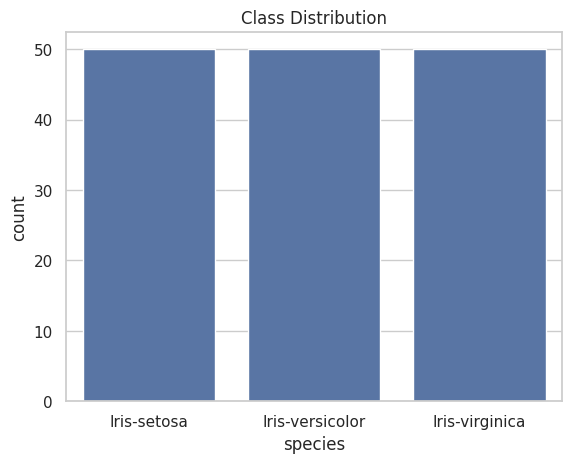

In [34]:
plt.figure()
sns.countplot(x='species', data=df)
plt.title("Class Distribution")
plt.show()

In [7]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
df.tail()


,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [13]:
print("The size of the dataset is : ",df.shape)


The size of the dataset is :  (150, 5)


In [16]:
print("Check whether null value is present in the dataset: \n", df.isnull())

Check weather null value is present in the dataset: 
      sepal_length  sepal_width  petal_length  petal_width  species
0           False        False         False        False    False
1           False        False         False        False    False
2           False        False         False        False    False
3           False        False         False        False    False
4           False        False         False        False    False
..            ...          ...           ...          ...      ...
145         False        False         False        False    False
146         False        False         False        False    False
147         False        False         False        False    False
148         False        False         False        False    False
149         False        False         False        False    False

[150 rows x 5 columns]


In [19]:
print(df['species'].value_counts())

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [21]:
print("Information of the dataset presenst :\n ")
print(df.info())

Information of the dataset presenst :
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


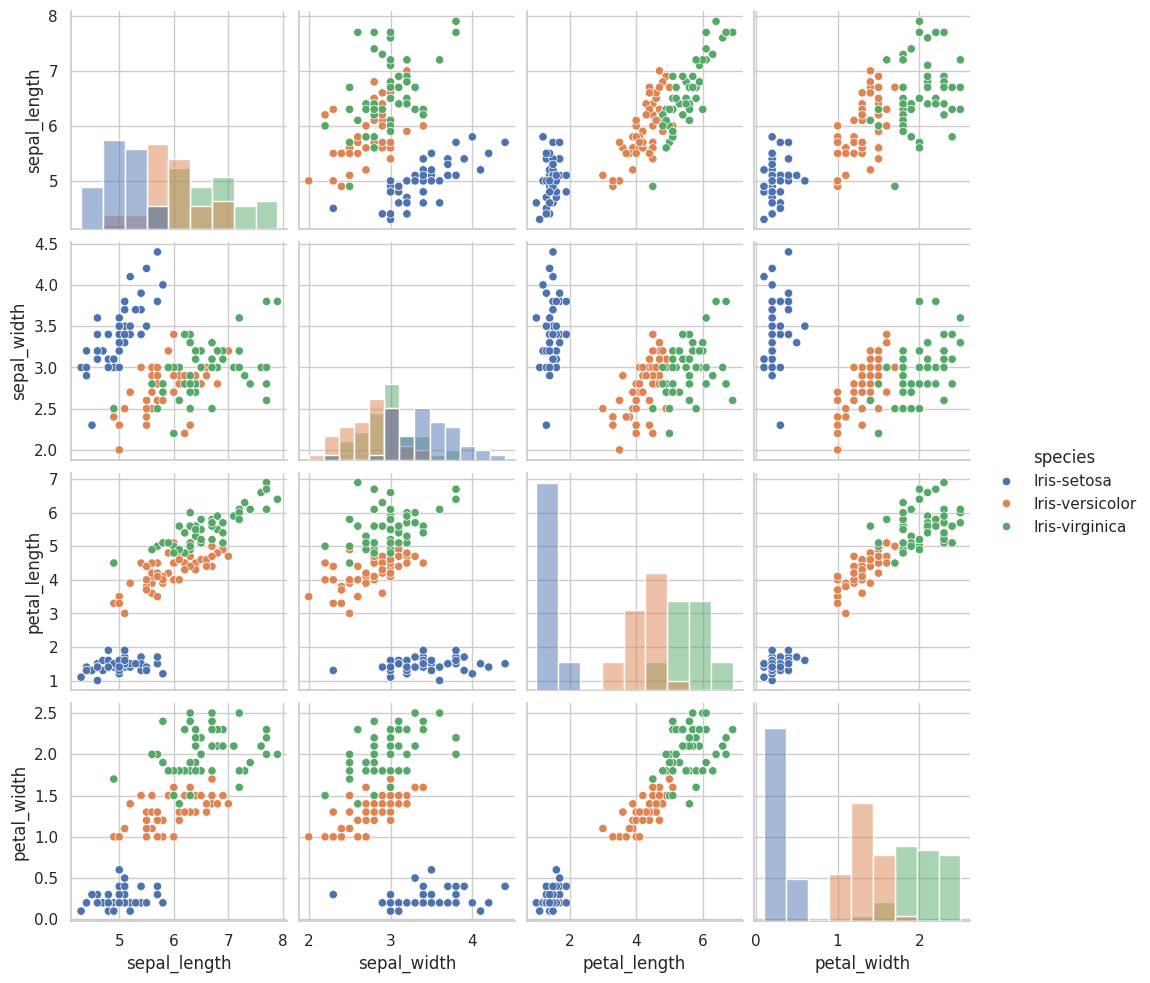

In [35]:
sns.pairplot(df, hue='species', diag_kind='hist')
plt.show()

In [23]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [25]:
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

print(le.classes_)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [26]:
#split the features and target
x = df.drop('species', axis = 1)
y = df['species']

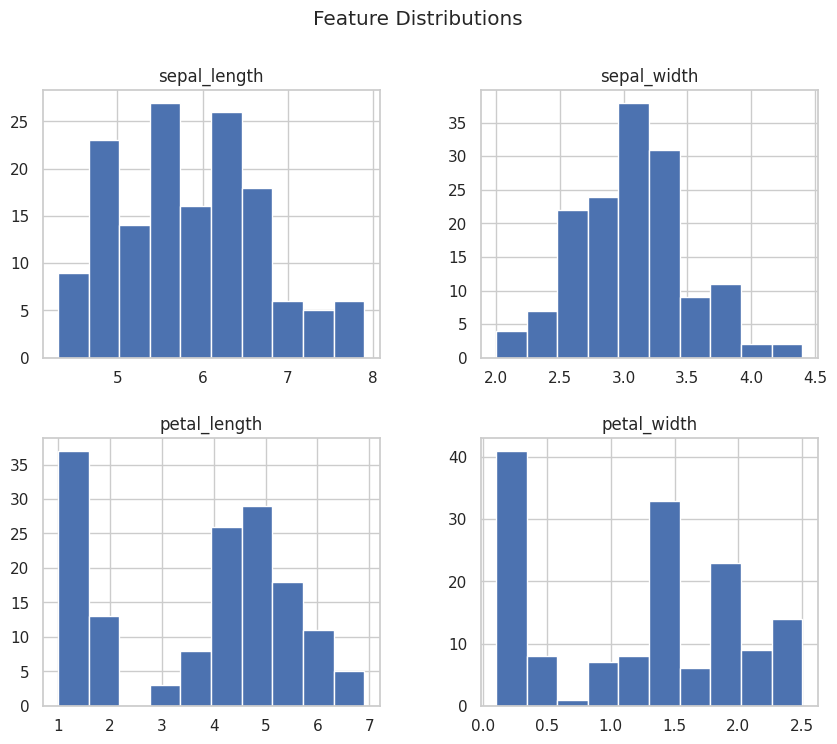

In [36]:
df.hist(figsize=(10, 8))
plt.suptitle("Feature Distributions")
plt.show()

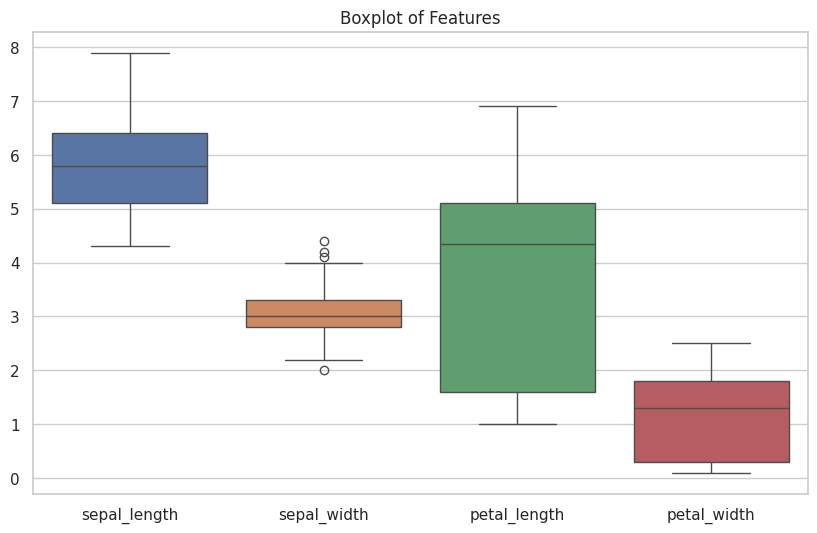

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop('species', axis=1))
plt.title("Boxplot of Features")
plt.show()

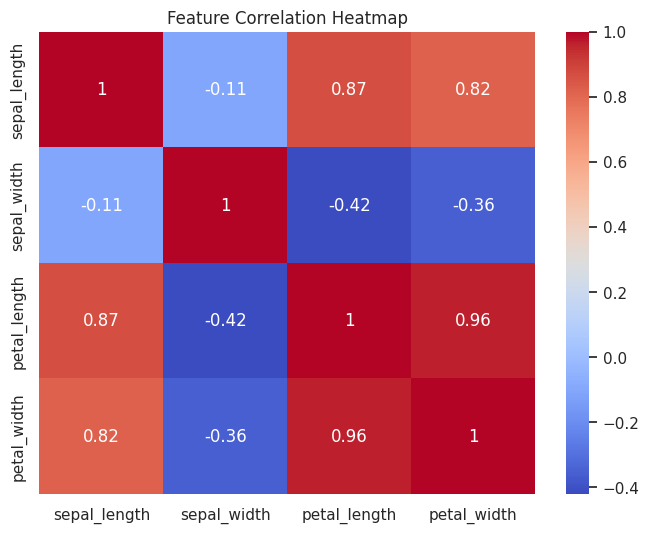

In [38]:
plt.figure(figsize=(8, 6))
corr = df.drop('species', axis=1).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

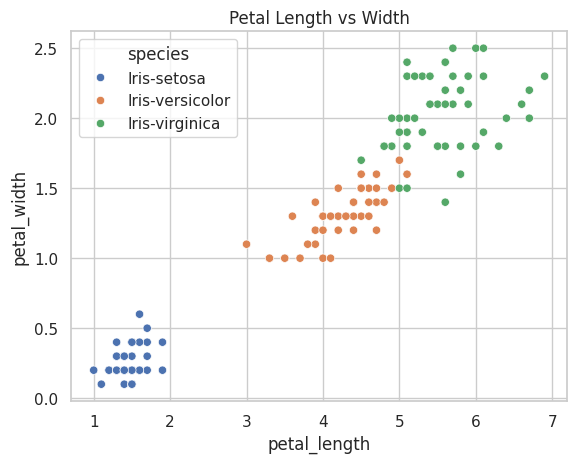

In [39]:
plt.figure()
sns.scatterplot(
    x='petal_length',
    y='petal_width',
    hue='species',
    data=df
)
plt.title("Petal Length vs Width")
plt.show()

In [28]:
#Train-TEST-SPLIT
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2 , random_state = 42, stratify = y)

In [30]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
  ('classifier', LogisticRegression(max_iter = 200 ))
])

In [32]:
cv_scores = cross_val_score(
    pipeline,
    x_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("cv scores:", cv_scores)
print("Mean CV Accuracy: ",np.mean(cv_scores))

cv scores: [0.91666667 0.95833333 0.95833333 0.95833333 1.        ]
Mean CV Accuracy:  0.9583333333333334


In [46]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'classifier__C': 10, 'classifier__solver': 'lbfgs'}
Best CV Score: 0.9666666666666668


In [47]:
best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


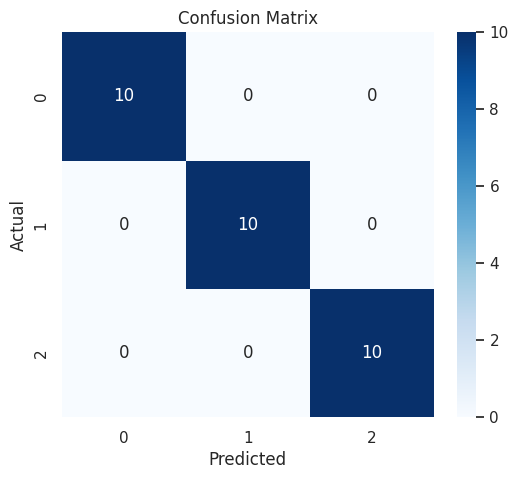

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

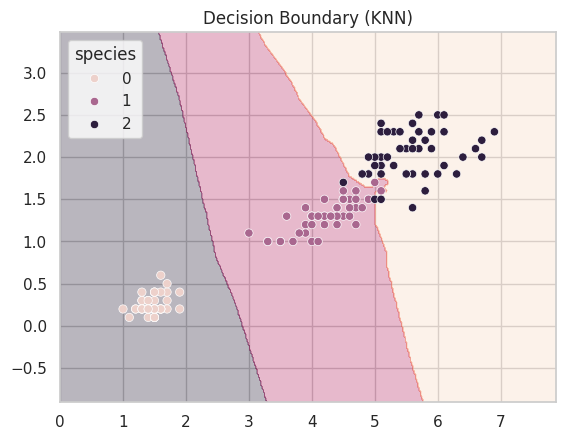

In [53]:
from matplotlib.colors import ListedColormap

# Use only 2 features
x_vis = df[['petal_length', 'petal_width']].values
y_vis = y # Use the numerical species labels from the 'y' variable

from sklearn.neighbors import KNeighborsClassifier
model_vis = KNeighborsClassifier(n_neighbors=3)
model_vis.fit(x_vis, y_vis)

# Meshgrid
x_min, x_max = x_vis[:, 0].min() - 1, x_vis[:, 0].max() + 1
y_min, y_max = x_vis[:, 1].min() - 1, x_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
sns.scatterplot(
    x=x_vis[:, 0],
    y=x_vis[:, 1],
    hue=y_vis
)
plt.title("Decision Boundary (KNN)")
plt.show()

In [49]:
predicted_labels = le.inverse_transform(y_pred[:5])
print(predicted_labels)

['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa']
